In [6]:
import numpy as np
import matplotlib.pyplot as plt



In [7]:
# 設定參數
delta_total = 0      # 系統初始/總體同位素組成 (permille)
epsilon_rev = -200   # 用較大的 epsilon 來呈現非線性效應 (H 同位素常見)
epsilon_ray = -20    # 用較小的 epsilon 呈現標準的瑞利分餾效果 (C/N 常見)

# ---------------------------------------------------------
# 1. 封閉可逆反應推導 (Closed Reversible: A <-> B)
# ---------------------------------------------------------
f_B = np.linspace(0, 1, 100)
f_A = 1 - f_B
alpha_rev = 1 + epsilon_rev / 1000

# 精確解 (Exact Solution - Fig 5)
# 基於質量守恆與平衡分餾公式
delta_B_exact = (delta_total - f_A * epsilon_rev) / (alpha_rev * f_A + f_B)
delta_A_exact = (alpha_rev * delta_total + f_B * epsilon_rev) / (alpha_rev * f_A + f_B)

# 近似解 (Linear Approximation - Fig 3)
delta_A_approx = delta_total + f_B * epsilon_rev
delta_B_approx = delta_total - f_A * epsilon_rev

# ---------------------------------------------------------
# 2. 封閉不可逆反應推導 (Rayleigh Distillation: A -> B)
# ---------------------------------------------------------
f_rem = np.linspace(1, 0.01, 100)  # 殘留反應物分率 (從 1 變到 0.01)
alpha_ray = 1 + epsilon_ray / 1000

# 殘留反應物 (Residual Reactant)
# Formula: R = R0 * f^(alpha-1)
delta_R = (delta_total + 1000) * (f_rem**(alpha_ray - 1)) - 1000

# 瞬時生成物 (Instantaneous Product)
# Formula: delta_P_inst = alpha * (delta_R + 1000) - 1000
delta_P_inst = alpha_ray * (delta_R + 1000) - 1000

# 累積生成物 (Cumulative Product)
# 基於質量守恆：delta_total = f*delta_R + (1-f)*delta_P_cum
delta_P_cum = (delta_total - f_rem * delta_R) / (1 - f_rem)

/tmp/ipykernel_193/3499844681.py:38: RuntimeWarning: invalid value encountered in divide
  delta_P_cum = (delta_total - f_rem * delta_R) / (1 - f_rem)


<>:4: SyntaxWarning: invalid escape sequence '\d'
<>:5: SyntaxWarning: invalid escape sequence '\d'
<>:6: SyntaxWarning: invalid escape sequence '\d'
<>:7: SyntaxWarning: invalid escape sequence '\d'
<>:11: SyntaxWarning: invalid escape sequence '\d'
<>:16: SyntaxWarning: invalid escape sequence '\d'
<>:17: SyntaxWarning: invalid escape sequence '\d'
<>:18: SyntaxWarning: invalid escape sequence '\d'
<>:22: SyntaxWarning: invalid escape sequence '\d'
<>:4: SyntaxWarning: invalid escape sequence '\d'
<>:5: SyntaxWarning: invalid escape sequence '\d'
<>:6: SyntaxWarning: invalid escape sequence '\d'
<>:7: SyntaxWarning: invalid escape sequence '\d'
<>:11: SyntaxWarning: invalid escape sequence '\d'
<>:16: SyntaxWarning: invalid escape sequence '\d'
<>:17: SyntaxWarning: invalid escape sequence '\d'
<>:18: SyntaxWarning: invalid escape sequence '\d'
<>:22: SyntaxWarning: invalid escape sequence '\d'
/tmp/ipykernel_193/2191877931.py:4: SyntaxWarning: invalid escape sequence '\d'
  ax1.plot

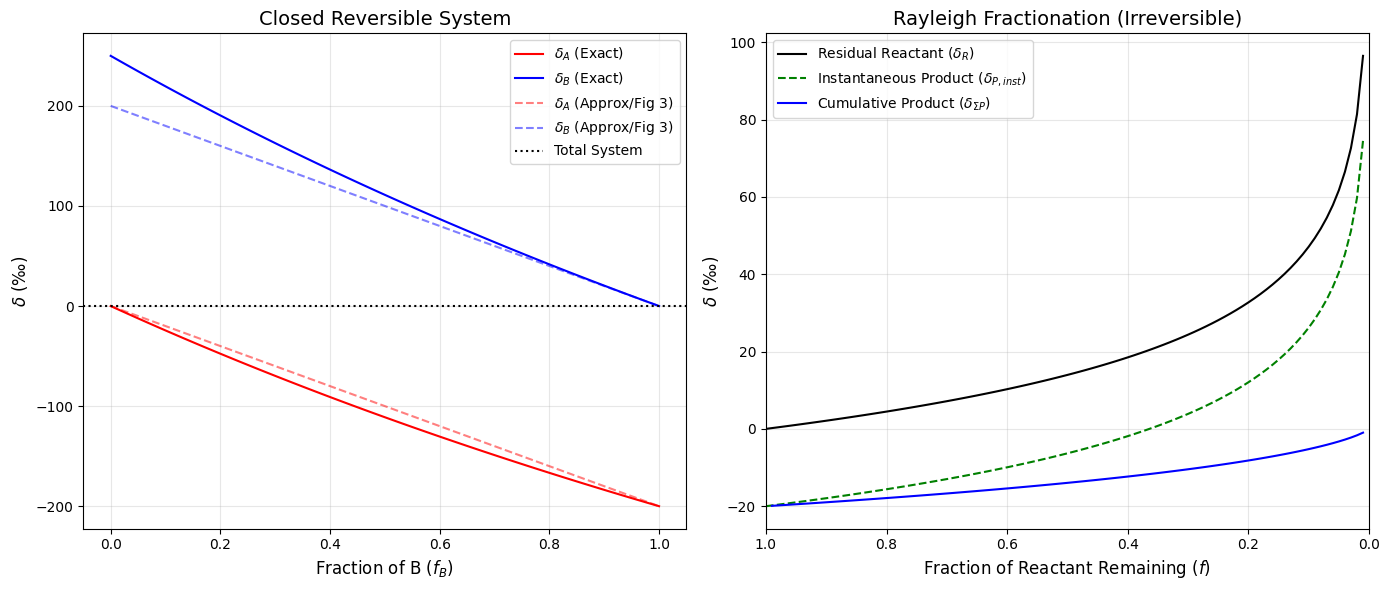

In [9]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

# 左圖(可逆)
ax1.plot(f_B, delta_A_exact, 'r-', label='$\delta_A$ (Exact)')
ax1.plot(f_B, delta_B_exact, 'b-', label='$\delta_B$ (Exact)')
ax1.plot(f_B, delta_A_approx, 'r--', alpha=0.5, label='$\delta_A$ (Approx/Fig 3)')
ax1.plot(f_B, delta_B_approx, 'b--', alpha=0.5, label='$\delta_B$ (Approx/Fig 3)')
ax1.axhline(y=delta_total, color='k', linestyle=':', label='Total System')
ax1.set_title('Closed Reversible System', fontsize=14)
ax1.set_xlabel('Fraction of B ($f_B$)', fontsize=12)
ax1.set_ylabel('$\delta$ (‰)', fontsize=12)
ax1.legend()
ax1.grid(True, alpha=0.3)

# 右圖(瑞利分餾)
ax2.plot(f_rem, delta_R, 'k-', label='Residual Reactant ($\delta_R$)')
ax2.plot(f_rem, delta_P_inst, 'g--', label='Instantaneous Product ($\delta_{P,inst}$)')
ax2.plot(f_rem, delta_P_cum, 'b-', label='Cumulative Product ($\delta_{\Sigma P}$)')
ax2.set_xlim(1.0, 0) # 瑞利圖通常從 f=1 到 f=0
ax2.set_title('Rayleigh Fractionation (Irreversible)', fontsize=14)
ax2.set_xlabel('Fraction of Reactant Remaining ($f$)', fontsize=12)
ax2.set_ylabel('$\delta$ (‰)', fontsize=12)
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()